<div align="center">

<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>


<img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg"
     alt="Python"
     width="80"
     height="80"/>
<img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/docker/docker-original.svg"
     alt="Docker"
     width="80"
     height="80"/>
<img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/scikitlearn/scikitlearn-original.svg"
     alt="scikit-learn"
     width="80"
     height="80"/>

![Python](https://img.shields.io/badge/Python-3.11-3776AB?style=flat-square&logo=python&logoColor=white)
![Docker](https://img.shields.io/badge/Docker-2496ED?style=flat-square&logo=docker&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat-square&logo=scikit-learn&logoColor=white)

<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>

</div>

In [1]:
# Obs: se você não estiver utilizando o ambiente virtual do módulo, instale as dependências:
# %pip install -q -r ../requirements.txt

---

<div align="center">

## <span style="color:#1E90FF;">Análise Exploratória de Dados</span>

</div>

Este notebook realiza a **análise exploratória completa** do dataset do trocador de calor (`heat_exchanger.db`), base do case utilizado ao longo do curso.

O objetivo é entender a estrutura, qualidade e comportamento dos dados **antes** de construir qualquer modelo preditivo. As observações aqui levantadas justificam as escolhas de pré-processamento e modelagem feitas nos scripts de produção (`train.py` e `inference.py`).

As etapas desta análise são:

- **Carregamento**: leitura do banco SQLite com todas as colunas disponíveis;
- **Qualidade dos dados**: tipos, valores nulos, intervalos esperados;
- **Estatísticas descritivas**: resumo numérico de cada variável;
- **Evolução temporal**: comportamento das variáveis ao longo do período;
- **Distribuições**: forma e simetria de cada feature;
- **Correlações**: relações lineares entre variáveis;
- **Tendência de degradação**: quantificação e visualização do decaimento da eficiência.

---

<div align="center">

## <span style="color:#1E90FF;">O Processo: Trocador de Calor</span>

</div>

<div align="center">
<img src="../img/heat_exchanger.png" alt="Diagrama de um trocador de calor casco-e-tubos" width="60%"/>
</div>

Um **trocador de calor** é um equipamento industrial que transfere energia térmica entre dois fluidos sem misturá-los. No case deste curso, trabalhamos com um modelo **casco-e-tubos** (*shell-and-tube*), o tipo mais comum em processos industriais.

**Como funciona:**

- O fluido quente (glicol, ~85 °C) circula pelo **casco** (*shell side*), envolvendo externamente os tubos;
- O fluido frio (água, ~33 °C) percorre o interior dos **tubos** (*tube side*) em contraflujo;
- A diferença de temperatura entre os fluidos gera o fluxo de calor — do glicol para a água;
- A **eficiência térmica** mede o quanto da troca de calor possível está efetivamente ocorrendo.

**Por que a eficiência cai com o tempo?**

Com o uso contínuo, incrustações minerais e depósitos orgânicos (*fouling*) se acumulam na superfície interna dos tubos, criando uma resistência térmica adicional. Esse fenômeno é gradual e progressivo — a eficiência decai de forma aproximadamente linear ao longo dos meses.

O objetivo do modelo preditivo é **estimar a eficiência futura** a partir do histórico temporal, permitindo antecipar a necessidade de limpeza ou manutenção antes que a operação seja impactada.

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DB_PATH = os.getenv('DB_PATH', '../data/heat_exchanger.db')

---

<div align="center">

## <span style="color:#1E90FF;">Carregamento dos Dados</span>

</div>

O dataset está armazenado num banco **SQLite** com uma única tabela (`heat_exchanger`). Carregamos todas as colunas disponíveis para a análise exploratória — diferente do `train.py`, que seleciona apenas as colunas necessárias para o modelo.

In [3]:
engine = create_engine(f"sqlite:///{DB_PATH}")
df = pd.read_sql_query(
    'SELECT * FROM heat_exchanger ORDER BY timestamp',
    engine,
)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_index'] = (df['timestamp'] - df['timestamp'].min()).dt.days

print(f'Shape             : {df.shape}')
print(f'Período           : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Total de registros: {len(df)}')
print(f'Colunas           : {list(df.columns)}')

df.head()

Shape             : (175, 7)
Período           : 2025-09-29 → 2026-03-28
Total de registros: 175
Colunas           : ['timestamp', 'water_inlet_temperature', 'glycol_inlet_temperature', 'out_glycol_temperature', 'out_water_temperature', 'heat_efficiency', 'day_index']


,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency,day_index
0,2025-09-29,33.49,85.82,46.50,61.808856,96.454517,0
1,2025-09-30,33.51,86.35,46.75,61.894941,96.432576,1
2,2025-10-01,33.39,85.98,46.55,61.672872,96.410674,2
3,2025-10-02,33.32,85.71,46.51,61.403079,96.388810,3
4,2025-10-03,32.86,87.54,46.71,61.583481,96.366986,4


---

<div align="center">

## <span style="color:#1E90FF;">Qualidade dos Dados</span>

</div>

Verificamos os tipos de cada coluna, a presença de valores nulos e os intervalos observados. Esta etapa é essencial antes de qualquer modelagem — dados com missing values ou outliers extremos exigem tratamento explícito.

In [4]:
print('=== Tipos de dados ===')
print(df.dtypes)

print('\n=== Valores nulos por coluna ===')
nulls = df.isnull().sum()
print(nulls)
print(f'\nTotal de nulos: {nulls.sum()} — dataset {"limpo ✓" if nulls.sum() == 0 else "com missing values ⚠️"}')

print('\n=== Intervalos das variáveis numéricas ===')
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    n_null = df[col].isnull().sum()
    null_str = f'  ({n_null} nulos)' if n_null else ''
    print(f'  {col:<35s}: [{df[col].min():.3f}, {df[col].max():.3f}]{null_str}')

# --- Detecção de outliers via IQR ---
print('\n=== Outliers detectados (método IQR) ===')
feat_cols = [c for c in num_cols if c != 'day_index']
outlier_summary = {}
for col in feat_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    outlier_rows = df[mask][['timestamp', col]]
    outlier_summary[col] = mask.sum()
    if not outlier_rows.empty:
        print(f'\n  {col} — {mask.sum()} outlier(s):')
        print(outlier_rows.to_string(index=True))

print(f'\nTotal de outliers (IQR): {sum(outlier_summary.values())}')

=== Tipos de dados ===
timestamp                   datetime64[us]
water_inlet_temperature            float64
glycol_inlet_temperature           float64
out_glycol_temperature             float64
out_water_temperature              float64
heat_efficiency                    float64
day_index                            int64
dtype: object

=== Valores nulos por coluna ===
timestamp                   0
water_inlet_temperature     0
glycol_inlet_temperature    0
out_glycol_temperature      0
out_water_temperature       0
heat_efficiency             0
day_index                   0
dtype: int64

Total de nulos: 0 — dataset limpo ✓

=== Intervalos das variáveis numéricas ===
  water_inlet_temperature            : [20.850, 35.930]
  glycol_inlet_temperature           : [21.110, 89.180]
  out_glycol_temperature             : [20.700, 48.970]
  out_water_temperature              : [21.263, 64.061]
  heat_efficiency                    : [93.225, 96.455]
  day_index                          : [0.00

---

<div align="center">

## <span style="color:#1E90FF;">Estatísticas Descritivas</span>

</div>

O `describe()` fornece um resumo rápido de cada variável numérica: média, desvio padrão, quartis e extremos. Valores de desvio padrão baixos em variáveis de temperatura podem indicar condições operacionais estáveis — o que é esperado para um processo industrial controlado.

In [5]:
df.drop(columns=['day_index']).describe().round(4)

,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency
count,175,175.0000,175.0000,175.0000,175.0000,175.0000
mean,2025-12-27 08:21:56.571428,31.4419,69.6994,41.3503,51.4613,94.7418
min,2025-09-29 00:00:00,20.8500,21.1100,20.7000,21.2630,93.2253
25%,2025-11-11 12:00:00,30.9100,31.5450,31.5650,33.1288,93.9216
50%,2025-12-27 00:00:00,32.1000,84.1300,45.5800,59.2506,94.6919
75%,2026-02-10 12:00:00,32.7700,85.8450,46.4850,60.1072,95.5362
max,2026-03-28 00:00:00,35.9300,89.1800,48.9700,64.0610,96.4545
std,NaN,2.3823,24.7810,7.6865,13.8722,0.9413


---

<div align="center">

## <span style="color:#1E90FF;">Evolução Temporal</span>

</div>

Visualizamos o comportamento de todas as variáveis ao longo do tempo. O padrão esperado para um trocador de calor em degradação é:

- **Eficiência térmica**: queda monotônica ao longo do período;
- **Temperaturas**: relativamente estáveis, com flutuações operacionais.

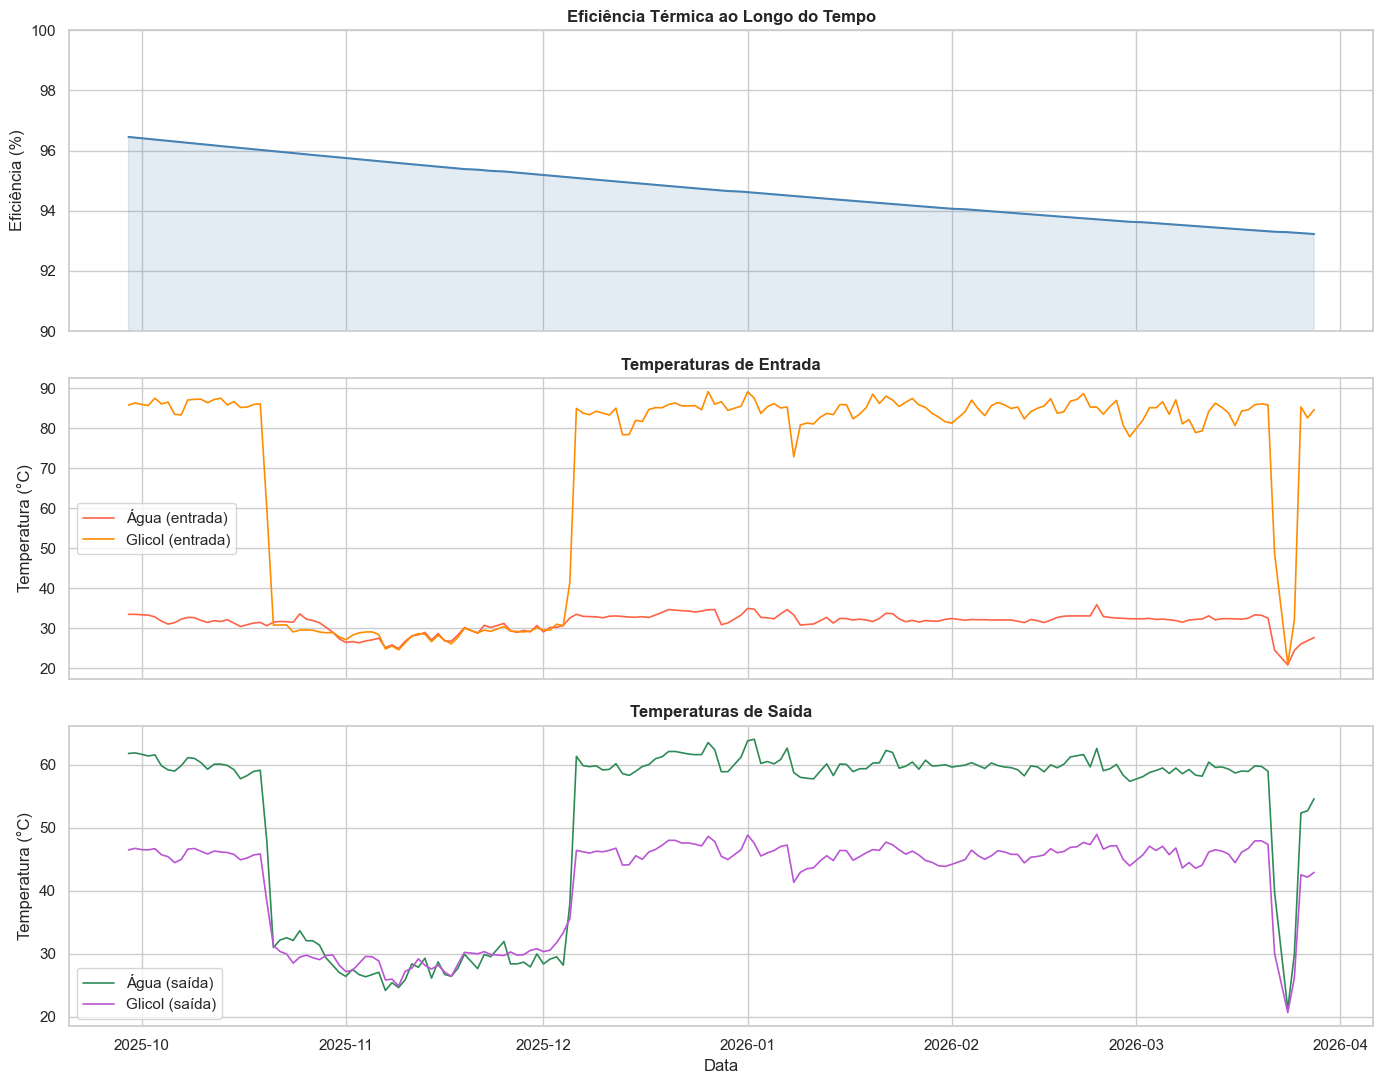

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# --- Eficiência térmica ---
axes[0].plot(df['timestamp'], df['heat_efficiency'], color='steelblue', linewidth=1.5)
axes[0].set_title('Eficiência Térmica ao Longo do Tempo', fontweight='bold')
axes[0].set_ylabel('Eficiência (%)')
axes[0].set_ylim(90, 100)
axes[0].fill_between(df['timestamp'], df['heat_efficiency'], alpha=0.15, color='steelblue')

# --- Temperaturas de entrada ---
axes[1].plot(df['timestamp'], df['water_inlet_temperature'],
             label='Água (entrada)', color='tomato', linewidth=1.2)
axes[1].plot(df['timestamp'], df['glycol_inlet_temperature'],
             label='Glicol (entrada)', color='darkorange', linewidth=1.2)
axes[1].set_title('Temperaturas de Entrada', fontweight='bold')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].legend()

# --- Temperaturas de saída ---
axes[2].plot(df['timestamp'], df['out_water_temperature'],
             label='Água (saída)', color='seagreen', linewidth=1.2)
axes[2].plot(df['timestamp'], df['out_glycol_temperature'],
             label='Glicol (saída)', color='mediumorchid', linewidth=1.2)
axes[2].set_title('Temperaturas de Saída', fontweight='bold')
axes[2].set_ylabel('Temperatura (°C)')
axes[2].set_xlabel('Data')
axes[2].legend()

plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Distribuições</span>

</div>

Histogramas e boxplots revelam a forma das distribuições de cada variável. Distribuições simétricas e sem outliers extremos indicam um processo estável. Assimetrias ou caudas longas podem indicar eventos operacionais anômalos.

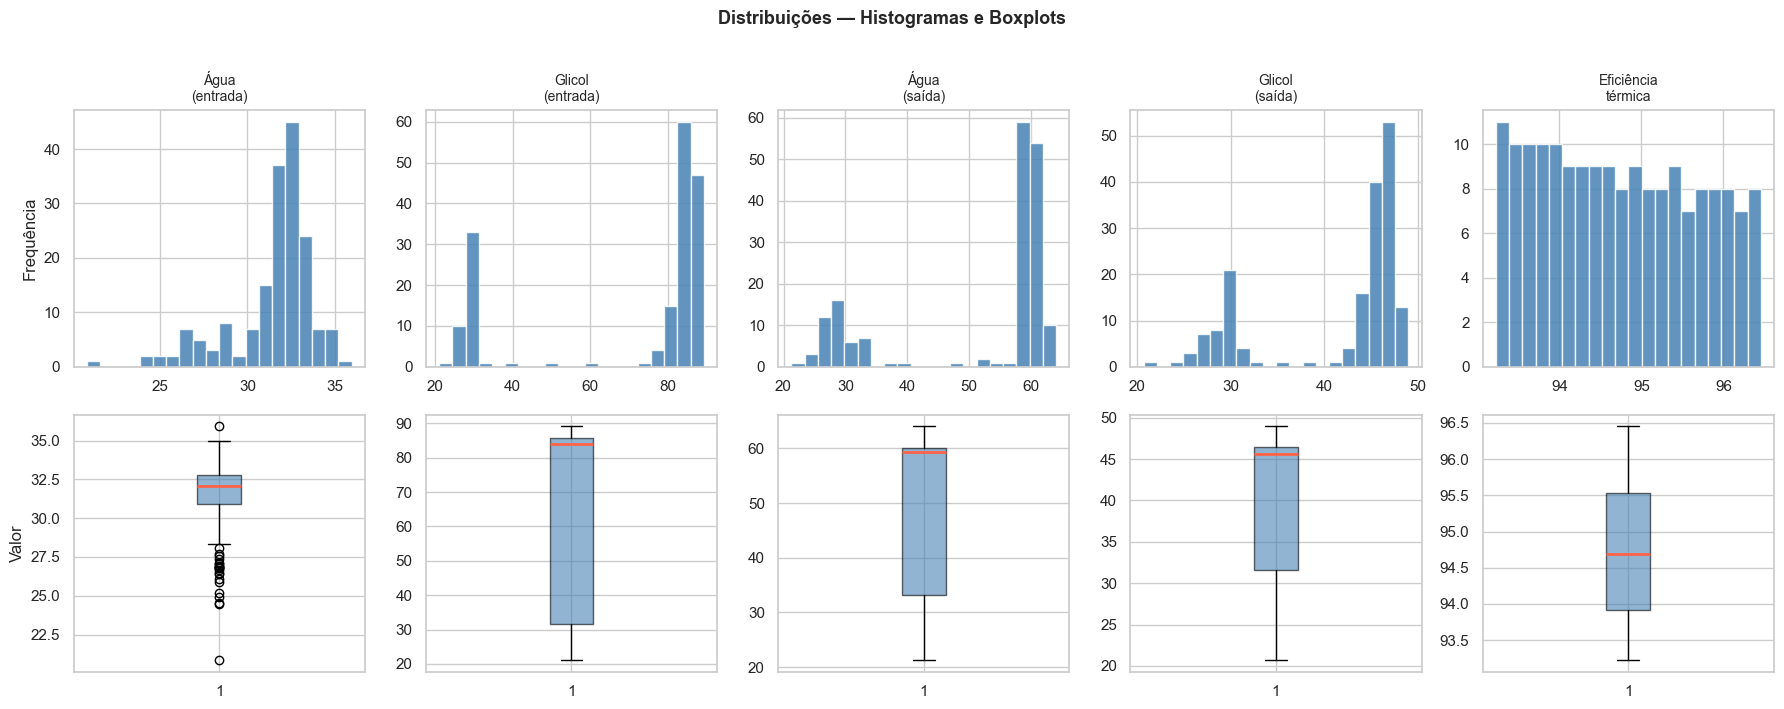

In [7]:
feat_cols = [
    'water_inlet_temperature', 'glycol_inlet_temperature',
    'out_water_temperature', 'out_glycol_temperature', 'heat_efficiency',
]
labels = [
    'Água\n(entrada)', 'Glicol\n(entrada)',
    'Água\n(saída)', 'Glicol\n(saída)', 'Eficiência\ntérmica',
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, (col, lbl) in enumerate(zip(feat_cols, labels)):
    # Histograma
    axes[0, i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(lbl, fontsize=10)
    axes[0, i].set_ylabel('Frequência' if i == 0 else '')

    # Boxplot
    bp = axes[1, i].boxplot(
        df[col], vert=True, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='tomato', linewidth=2),
    )
    axes[1, i].set_ylabel('Valor' if i == 0 else '')

plt.suptitle('Distribuições — Histogramas e Boxplots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Correlações</span>

</div>

A matriz de correlação quantifica a relação linear entre pares de variáveis. Para este dataset, esperamos:

- **`day_index` × `heat_efficiency`**: correlação negativa forte — a eficiência cai com o tempo;
- **Temperaturas entre si**: possivelmente correlacionadas por física do processo;
- **Temperaturas × `heat_efficiency`**: correlação que pode revelar quais variáveis físicas mais impactam a eficiência.

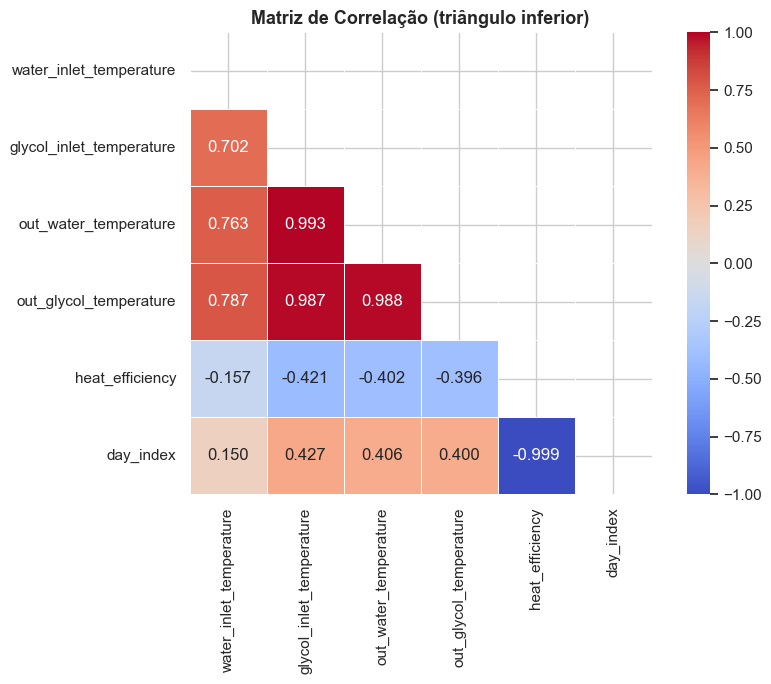

In [8]:
corr_cols = [
    'water_inlet_temperature', 'glycol_inlet_temperature',
    'out_water_temperature', 'out_glycol_temperature',
    'heat_efficiency', 'day_index',
]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
)
plt.title('Matriz de Correlação (triângulo inferior)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Tendência de Degradação</span>

</div>

Esta é a análise central do EDA. Quantificamos a taxa de degradação da eficiência térmica ao longo do tempo ajustando uma reta de tendência sobre `day_index` via `np.polyfit`.

O objetivo aqui é **exploratório**: verificar se a queda é monotônica e aproximadamente linear, e quantificar a taxa diária de degradação. A comparação formal entre algoritmos e a seleção do modelo final são realizadas no notebook `model_evaluation.ipynb`.

=== Tendência Linear: Eficiência × Tempo ===
  Coef. angular : -0.017919% por dia
  Intercepto   : 96.3428%
  R²            : 0.9975
  Variação total: -3.2254% em 180 dias


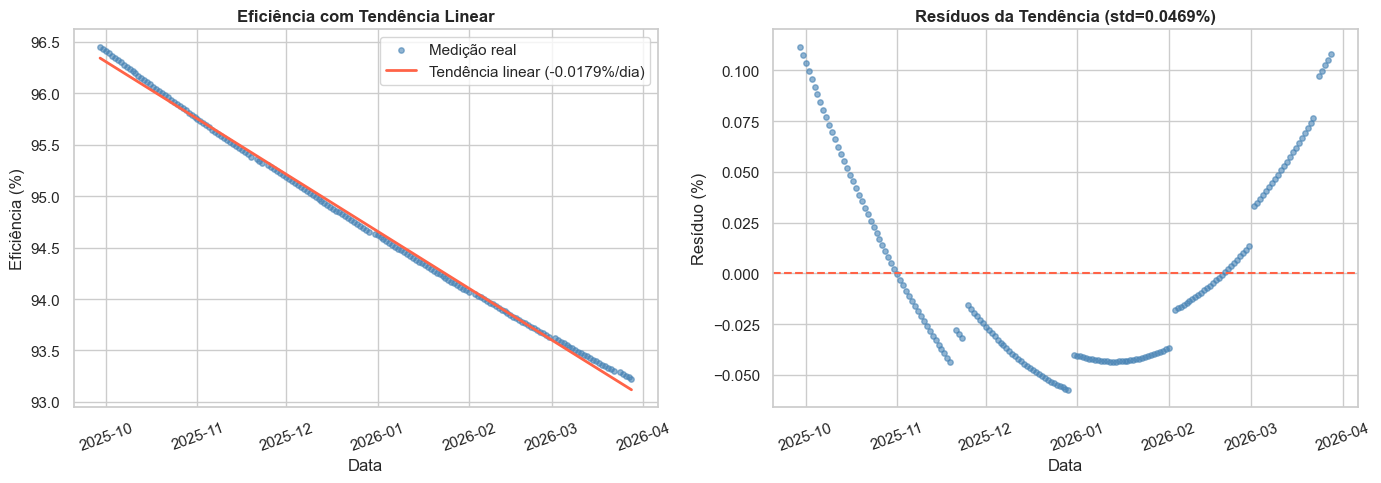


Conclusão: a queda é monotônica, a tendência é aproximadamente linear e
os resíduos são aleatórios — sem padrão estrutural remanescente.
→ Ver model_evaluation.ipynb para a comparação formal de algoritmos.


In [9]:
x = df['day_index'].values
y = df['heat_efficiency'].values

coef = np.polyfit(x, y, deg=1)          # [angular, intercepto]
trend = np.polyval(coef, x)
residuals = y - trend

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print('=== Tendência Linear: Eficiência × Tempo ===')
print(f'  Coef. angular : {coef[0]:.6f}% por dia')
print(f'  Intercepto   : {coef[1]:.4f}%')
print(f'  R²            : {r2:.4f}')
print(f'  Variação total: {trend[-1] - trend[0]:.4f}% em {int(x.max())} dias')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Série + tendência ---
axes[0].scatter(df['timestamp'], y, s=15, alpha=0.6, color='steelblue', label='Medição real', zorder=2)
axes[0].plot(
    df['timestamp'], trend, color='tomato', linewidth=2,
    label=f'Tendência linear ({coef[0]:.4f}%/dia)',
)
axes[0].set_title('Eficiência com Tendência Linear', fontweight='bold')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Eficiência (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=20)

# --- Resíduos ---
axes[1].scatter(df['timestamp'], residuals, s=15, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[1].set_title(f'Resíduos da Tendência (std={residuals.std():.4f}%)', fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Resíduo (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('\nConclusão: a queda é monotônica, a tendência é aproximadamente linear e')
print('os resíduos são aleatórios — sem padrão estrutural remanescente.')
print('→ Ver model_evaluation.ipynb para a comparação formal de algoritmos.')